# <center> Exploring Vienna's Airbnb Market Data </center>

## Project Overview

Airbnb prices can differ across internet listings, even within the same city. These differences may be explained by/ depend on the location of the listing, property characteristics, room type, capacity, reviews, availability and host status. 

The aim of this project is to analyse and study which characteristics are most important to Airbnb listing prices in Vienna and to use different statistical models to predict the price of a listing.

The guiding research question of this project is:
"Through exploratory analysis, how can Airbnb listing prices in Vienna be understood and explained using the variables defined in following section, and how does the predictive performance compare, between Lasso Regression and Random Forest, on the test data?"

## 1 Data Source & Preparation Information

This project uses the listings dataset from Inside Airbnb for Vienna. (Link reference: https://insideairbnb.com/get-the-data/)

The `listings.csv` dataset contains 13,283 Airbnb listings and 90 different variables. Of those 90 variables, only 16 independent variables will be used, as described in the following section.

### 1.1 Main Variables

The dependent variable is:

`price`: the nightly price of the Airbnb listing (using local currency).

The selected predictor variables are:

`superhost_status`: indicates whether the host has Airbnb Superhost status. <br>
`neighbourhood`: the Vienna neighbourhood in which the listing is located. <br>
`property_type`: the type of property, such as an apartment, house or hotel. <br>
`room_type`: indicates whether the listing is an entire home, private room, shared room or hotel room. <br>
`accommodates`: the maximum number of guests that can stay in the listing. <br>
`description_length`: length of the (detailed) description of the listing<br>
`amenities`: features and conveniences each listing offers to guests <br>
`bathrooms`: the number of bathrooms available in the listing. <br>
`bedrooms`: the number of bedrooms in the listing. <br>
`min_nights`: the minimum number of nights required for a booking. <br>
`availability_365`: the number of days during the following year on which the listing is available. <br>
`num_reviews`: the total number of reviews received by the listing. <br>
`rating`: the overall rating received by the listing.

The variable `bathrooms_text` contains the bathroom number in text form,e.g "1 bath", "1.5 baths" or "1 shared bath". It will be converted into only numbers.

`latitude` and `longitude` variables will only be used for a city heat-map showing.<br>
`host_id` will be used during the explanatory analysis.

All listings with missing information were removed from the dataset (dropped), and the prepared dataset which will be used will have in total 7,863 observations.

### 1.2 Model Selection

For this project, Lasso Regression and Random Forest Regression are selected.

`Lasso`: a regularization method that estimates the model and selects variables at the same time. It shrinks the coefficients of less important predictors (can even set some of them to zero). <br>
This is helpful for this dataset, as the categorical variables (e,g: neighbourhood and property type) will create many dummy variables.

`Random Forest`: a more flexible tree-based method. It combines the predictions of many trees and uses a random selection of predictors when each split is made. <br>
This reduces the correlation between the trees and can lower the variance of the final predictions. It's ability to capture nonlinear relationships and interactions between the listing characteristics is also useful.

These models were chosen, in order to make a comparison between a regularized linear model and a more flexible tree-based model.

## 2 Loading, cleaning, and preparing the data

In [1]:
# Libraries
import os 

import ast
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor

In [2]:
path = os.path.dirname(os.path.abspath('Airbnb_Analysis.ipynb')) # absolute directory 
print(path)

/workspaces/Vienna-Airbnb-Data-Analysis/notebook


In [3]:
df = pd.read_csv(path + '/../data/listings.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13283 entries, 0 to 13282
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            13283 non-null  int64  
 1   listing_url                                   13283 non-null  str    
 2   scrape_id                                     13283 non-null  int64  
 3   last_scraped                                  13283 non-null  str    
 4   source                                        13283 non-null  str    
 5   name                                          13283 non-null  str    
 6   description                                   12917 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   13282 non-null  str    
 9   host_id                                       13283 non-null  int64  
 1

In [4]:
variables = [
    'price',
    'host_id',
    'neighbourhood_cleansed',
    'property_type',
    'room_type',
    'accommodates',
    'description',
    'amenities',
    'bedrooms',
    'bathrooms_text',
    'minimum_nights',
    'availability_365',
    'host_is_superhost',
    'number_of_reviews',
    'review_scores_rating',
    'latitude',
    'longitude'
]

airbnb = df[variables]
airbnb.head(3)

,price,host_id,neighbourhood_cleansed,property_type,room_type,accommodates,description,amenities,bedrooms,bathrooms_text,minimum_nights,availability_365,host_is_superhost,number_of_reviews,review_scores_rating,latitude,longitude
0,NaN,53270069,Ottakring,Entire rental unit,Entire home/apt,4,The Apartment is located on the top floor of a...,"[""Kitchen"", ""Elevator"", ""Wifi"", ""Hangers"", ""Wa...",2.0,1 bath,5.0,0,f,0,NaN,48.21136,16.32806
1,NaN,78540887,Margareten,Entire rental unit,Entire home/apt,6,Very bright and warm apartment with modern kit...,"[""Kitchen"", ""Iron"", ""Elevator"", ""Wifi"", ""TV"", ...",3.0,1.5 baths,2.0,0,f,0,NaN,48.18514,16.34720
2,NaN,2764320,Leopoldstadt,Entire rental unit,Entire home/apt,4,Artistic authentic old Viennese apartment of c...,"[""Cooking basics"", ""Stove"", ""First aid kit"", ""...",1.0,1 bath,30.0,0,f,193,4.84,48.22375,16.40081


In [5]:
airbnb = airbnb.rename(columns={
    "description": "description_length",
    "bathrooms_text": "bathrooms",
    "neighbourhood_cleansed": "neighbourhoods",
    "host_is_superhost": "superhost_status",
    "minimum_nights": "min_nights",
    "number_of_reviews": "num_reviews",
    "review_scores_rating": "rating"

})
# All obs. with missing descriptions are cosidered as 0
airbnb['description_length'] = airbnb['description_length'].str.len().fillna(0)

airbnb = airbnb.dropna()

# Converting price to number
airbnb['price'] = airbnb['price'].str.replace(
    r"[$,]","", regex=True
    ).astype(float)

airbnb = airbnb.reset_index(drop= True)

# Making Superhost a binary variable
airbnb['superhost_status'] = airbnb['superhost_status'].map({
    "t": 1,
    "f": 0
})

# Fixing character problems (due to german special letters) in neighbourhood
airbnb['neighbourhoods'] = airbnb['neighbourhoods'].replace({
    "D\x9abling": "Döbling",
    "Landstra§e": "Landstraße",
    "Rudolfsheim-F\x9fnfhaus": "Rudolfsheim-Fünfhaus",
    "W\x8ahring": "Währing"
})

# Registering only the number of amenities per accommodation
airbnb['amenities']= airbnb['amenities'].apply(eval).apply(len)

In [6]:
airbnb.isna().sum()

price                 0
host_id               0
neighbourhoods        0
property_type         0
room_type             0
accommodates          0
description_length    0
amenities             0
bedrooms              0
bathrooms             0
min_nights            0
availability_365      0
superhost_status      0
num_reviews           0
rating                0
latitude              0
longitude             0
dtype: int64

In [7]:
airbnb.shape

(7863, 17)

In [8]:
# Converting text -> number for bathrooms
# Extracting the number  [anything without a digit ("Half-bath") -> NaN]
airbnb['bathrooms'] = pd.to_numeric(
    # \d+ -> one or more digits
    # \.? -> (if) decimal point
    # \d* -> digits of the decimal
    airbnb['bathrooms'].str.extract(r'(\d+\.?\d*)')[0], 
    errors='coerce'
)
# Fill in 0.5 for NaN
airbnb.loc[
    airbnb['bathrooms'].isna(),
    'bathrooms'
] = 0.5

In [9]:
# Spliting variables into categorial & numerical
categorical_variables = [
    "neighbourhoods",
    "property_type",
    "room_type"
]

airbnb['superhost_status'] = airbnb['superhost_status'].astype('category')
airbnb['neighbourhoods'] = airbnb['neighbourhoods'].astype('category')
airbnb['property_type'] = airbnb['property_type'].astype('category')
airbnb['room_type'] = airbnb['room_type'].astype('category')


numerical_variables = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "min_nights",
    "availability_365",
    "num_reviews",
    "rating"
]

airbnb['bedrooms'] = airbnb['bedrooms'].astype('int')
airbnb['min_nights'] = airbnb['min_nights'].astype('int')
airbnb['bathrooms'] = airbnb['bathrooms'].astype('category')

In [10]:
airbnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 7863 entries, 0 to 7862
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   price               7863 non-null   float64 
 1   host_id             7863 non-null   int64   
 2   neighbourhoods      7863 non-null   category
 3   property_type       7863 non-null   category
 4   room_type           7863 non-null   category
 5   accommodates        7863 non-null   int64   
 6   description_length  7863 non-null   float64 
 7   amenities           7863 non-null   int64   
 8   bedrooms            7863 non-null   int64   
 9   bathrooms           7863 non-null   category
 10  min_nights          7863 non-null   int64   
 11  availability_365    7863 non-null   int64   
 12  superhost_status    7863 non-null   category
 13  num_reviews         7863 non-null   int64   
 14  rating              7863 non-null   float64 
 15  latitude            7863 non-null   float64 
 16 

In [11]:
airbnb.to_csv(path +'/../data/airbnb.csv', index= False )

## 3 Exploratory Data Analysis

For this section, we will be exploring the data by analyzing its statistics and visualizing the values of features and correlations between different features. Explaining the process and the results.

In [12]:
airbnb.describe(include='all')

,price,host_id,neighbourhoods,property_type,room_type,accommodates,description_length,amenities,bedrooms,bathrooms,min_nights,availability_365,superhost_status,num_reviews,rating,latitude,longitude
count,7863.000000,7.863000e+03,7863,7863,7863,7863.000000,7863.000000,7863.000000,7863.000000,7863.0,7863.000000,7863.000000,7863.0,7863.000000,7863.000000,7863.000000,7863.000000
unique,NaN,NaN,23,36,4,NaN,NaN,NaN,NaN,18.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN
top,NaN,NaN,Leopoldstadt,Entire rental unit,Entire home/apt,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
freq,NaN,NaN,855,6170,7308,NaN,NaN,NaN,NaN,5855.0,NaN,NaN,5220.0,NaN,NaN,NaN,NaN
mean,151.265971,9.606456e+15,NaN,NaN,NaN,3.825003,368.925728,34.123235,1.415109,NaN,5.388401,222.398321,NaN,61.010174,4.712610,48.202983,16.360767
std,202.724638,1.266300e+17,NaN,NaN,NaN,1.914252,146.644042,12.787511,0.753275,NaN,13.063743,109.856765,NaN,92.104871,0.379048,0.023109,0.035942
min,4.550000,5.783000e+03,NaN,NaN,NaN,1.000000,0.000000,2.000000,1.000000,NaN,1.000000,0.000000,NaN,1.000000,1.000000,48.126310,16.209820
25%,91.500000,4.795788e+07,NaN,NaN,NaN,2.000000,288.000000,26.000000,1.000000,NaN,1.000000,135.000000,NaN,7.000000,4.620000,48.187538,16.335499
50%,124.390000,2.433320e+08,NaN,NaN,NaN,4.000000,416.000000,34.000000,1.000000,NaN,1.000000,244.000000,NaN,25.000000,4.810000,48.202110,16.359870
75%,170.020000,5.116899e+08,NaN,NaN,NaN,4.000000,481.000000,43.000000,2.000000,NaN,3.000000,325.000000,NaN,75.000000,4.940000,48.218959,16.382914


The dataset covers **7,863**  Vienna Airbnb listings across **23** neighbourhoods, with Leopoldstadt being the most common (855 listings, 11% of the total). 

The listings are dominated by **"Entire rental unit"** property types (6,170 listings, ~79%) and **"Entire home/apt"** room types (7,308 listings, over 92%), meaning this data is skewed heavily toward entire units of rentals rather than shared/private rooms. 

Pricing shows a mean of **151 &euro;**, a median of **124 &euro;**, and a max of **9,999 &euro;**. <br> 
*Mean > Median* just means that the price is has a tail that extends to the right (a small number of very expensive listings pull the average upward). 

The average listing accommodates about **3.8** guests, ranging from *1-16*, with most falling between 2 and 4, and typically has just 1 bedroom. The number of amenities average around **34 per listing** and are fairly symmetric. 

Minimum nights required has a median of only **1 night**, but the mean jumps to **5.4** nights (max 360), meaning most hosts allow short stays while a handful require much longer minimum stays, dragging the average up. Availability is similar, with listings available a mean of **222 days per year** (median 244) but a wide spread (min= 1 & max= 365). This suggest that some listings are essentially unavailable while others are open year-round. 

Reviews are heavily right-skewed as well, a mean of **61 reviews**,a median of **25 reviews** and a maximum of **1005 reviews**. This means a few standout listings with a high review count alongside a majority with less engagement. 

Ratings cluster very high **(mean 4.71, median 4.81, minimum 1.0)**, which is typical of the Airbnb business, with only a small number of low outliers forming a slight left tail.

### 3.1 Pairplot Distribution

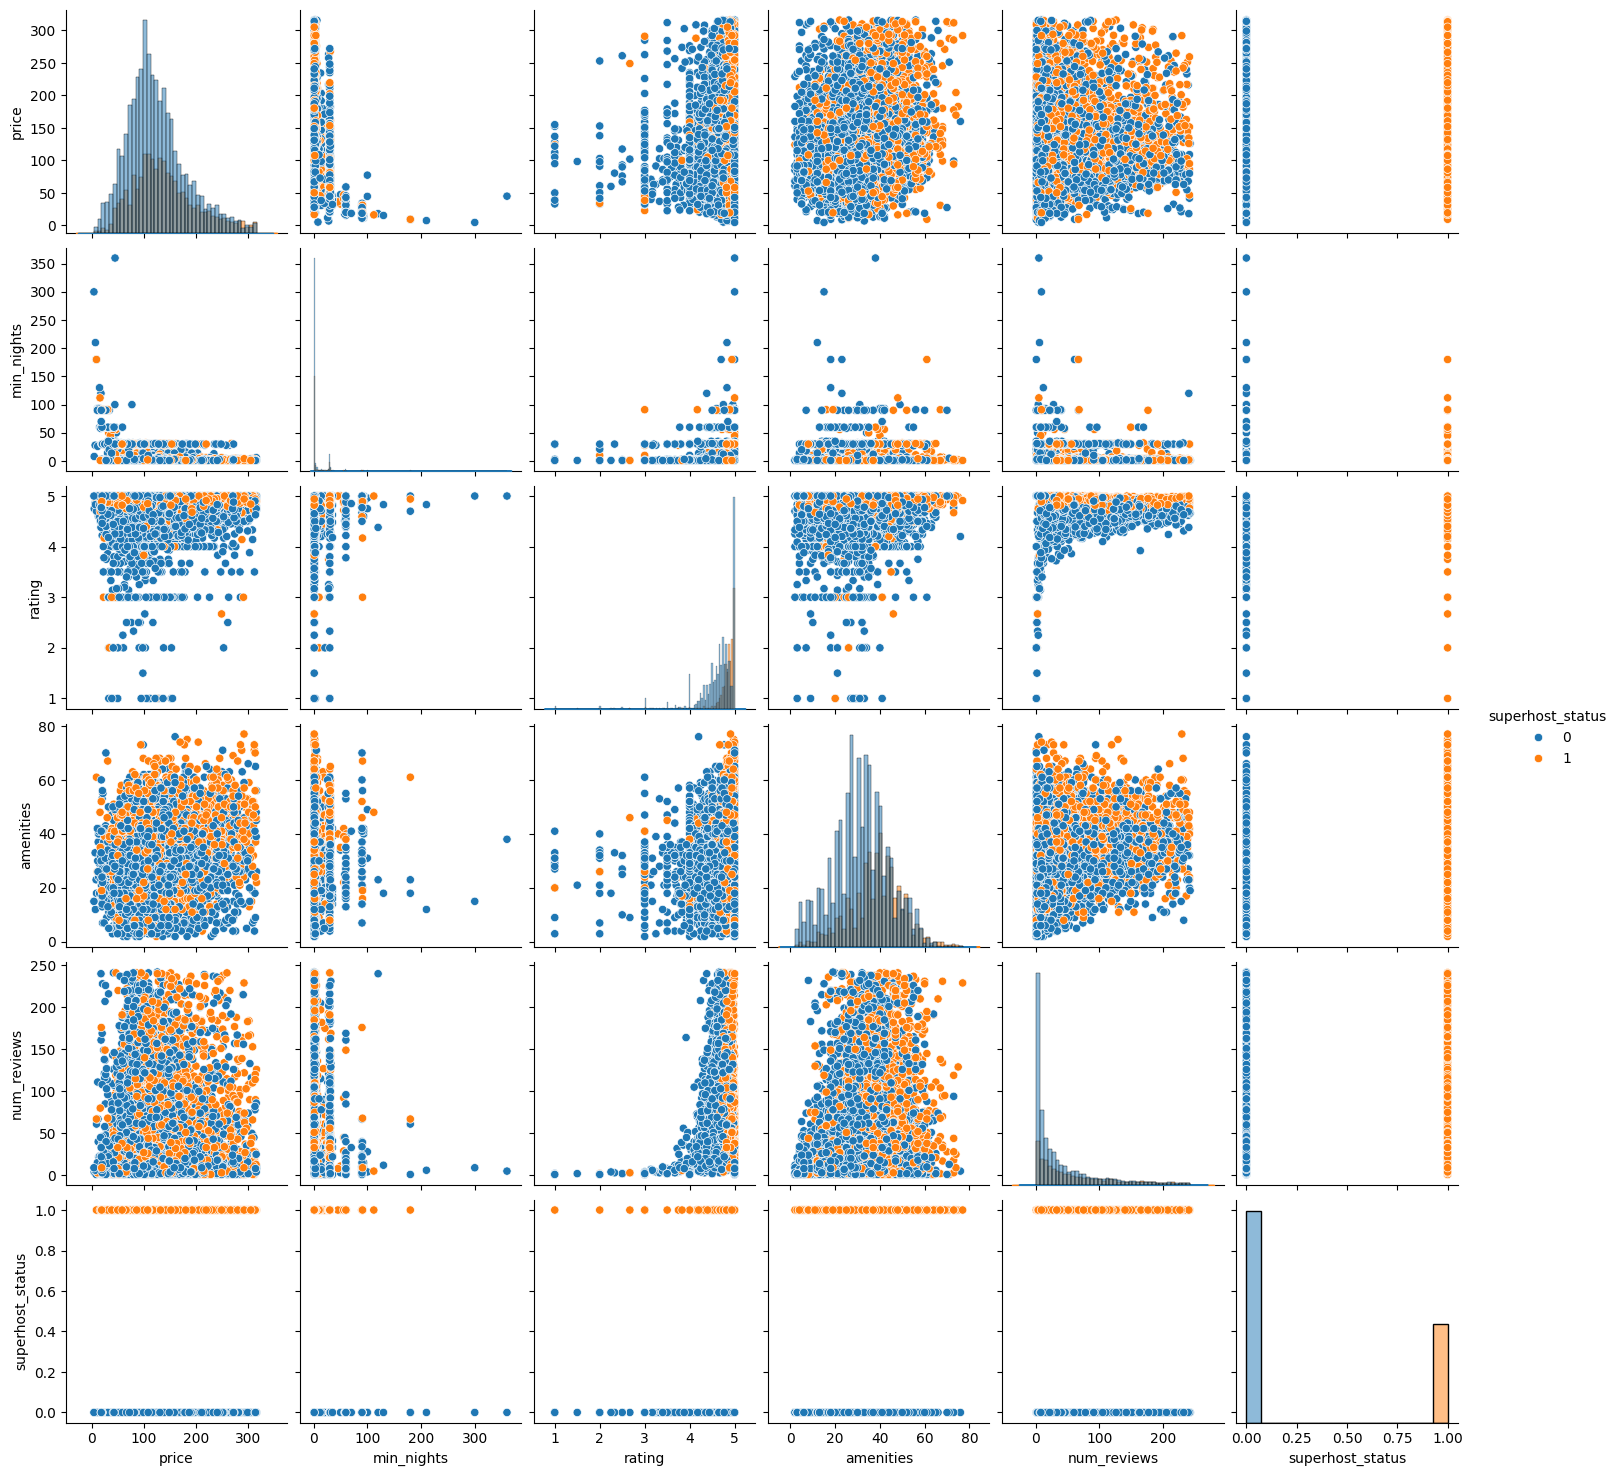

In [13]:
# Since price & number of reviews have extreme outliers, to read the plot:
p = airbnb[
    (airbnb['price'] < airbnb['price'].quantile(0.95)) &
    (airbnb['num_reviews'] < airbnb['num_reviews'].quantile(0.95))
]
p['superhost_status'] = p['superhost_status'].astype(int)

g = sns.pairplot(
    p,
    x_vars=['price','min_nights','rating','amenities','num_reviews','superhost_status'],
    y_vars=['price','min_nights','rating','amenities','num_reviews','superhost_status'],
    hue='superhost_status')

g.map_diag(sns.histplot)

plt.savefig(path + '/../Graphs/Pairplot.png')
plt.show()

The Pairplot created shows the following information: <br>
`price` is heavily right-skewed, with most listings clustering under 100 &euro;, with a long tail out to 300+ &euro; <br>
`min_nights` is extremely concentrated near 0, with almost no spread, meaning most listings require very few minimum nights, with only a handful of outliers. <br>
`rating` is mostly populated with 4-5 stars, with a smaller cluster of low outliers (people mostly either love or hate an accommodation) <br>
`amenities` look like a 'normal distribution' (bell shaped) <br>
`num_reviews` is sharply right-skewed, with most listings having very few reviews and a long tail of highly-reviewed places. <br>
`superhost_status` has more non-superhosts than superhosts in the data

**Interactions:**<br>
`amenities` vs. `price` --> My personal assumption before this project was that the number of amenities would affect price (positive interaction), however the scatter plot looks fairly flat, suggesting that the number of amenities alone isn't a strong price driver in this market<br>
`rating` vs. `num_reviews` --> Listings with more reviews tend to cluster toward higher ratings. <br>

### 3.2 Distribution of Airbnb prices

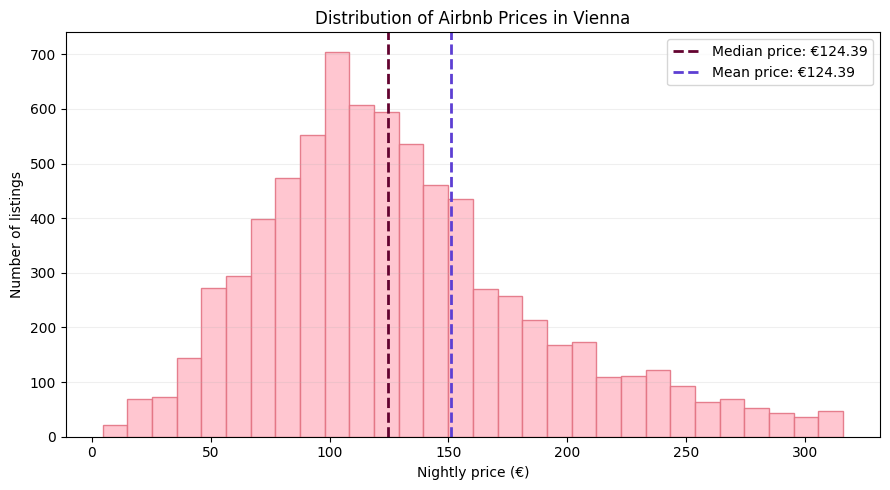

In [14]:
# Price limit
price_lim = airbnb['price'].quantile(0.95)

price_visual = airbnb[
    airbnb['price'] <= price_lim
].copy()

median_p = airbnb['price'].median()
mean_p = airbnb['price'].mean()

plt.figure(figsize=(9, 5))
plt.hist(
    price_visual['price'],
    color = '#FFC0CB',
    edgecolor = '#E37383',
    bins= 30,
    alpha = 0.9
)

plt.axvline(
    median_p,
    color= '#630330',
    linestyle= '--',
    linewidth= 2,
    label= f"Median price: €{median_p:.2f}"
)

plt.axvline(
    mean_p,
    color= '#5D3FD3',
    linestyle= '--',
    linewidth= 2,
    label= f"Mean price: €{median_p:.2f}"
)

plt.xlabel("Nightly price (€)")
plt.ylabel("Number of listings")
plt.title("Distribution of Airbnb Prices in Vienna")
plt.legend()

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.savefig(path + '/../Graphs/Distribution_Prices.png')
plt.show()

########### Short Comment on graph

### 3.3 Distribution of listings across neighbourhoods
Airbnb activity is not distributed equally across the city. The following graph shows the  skewness of the distribution.

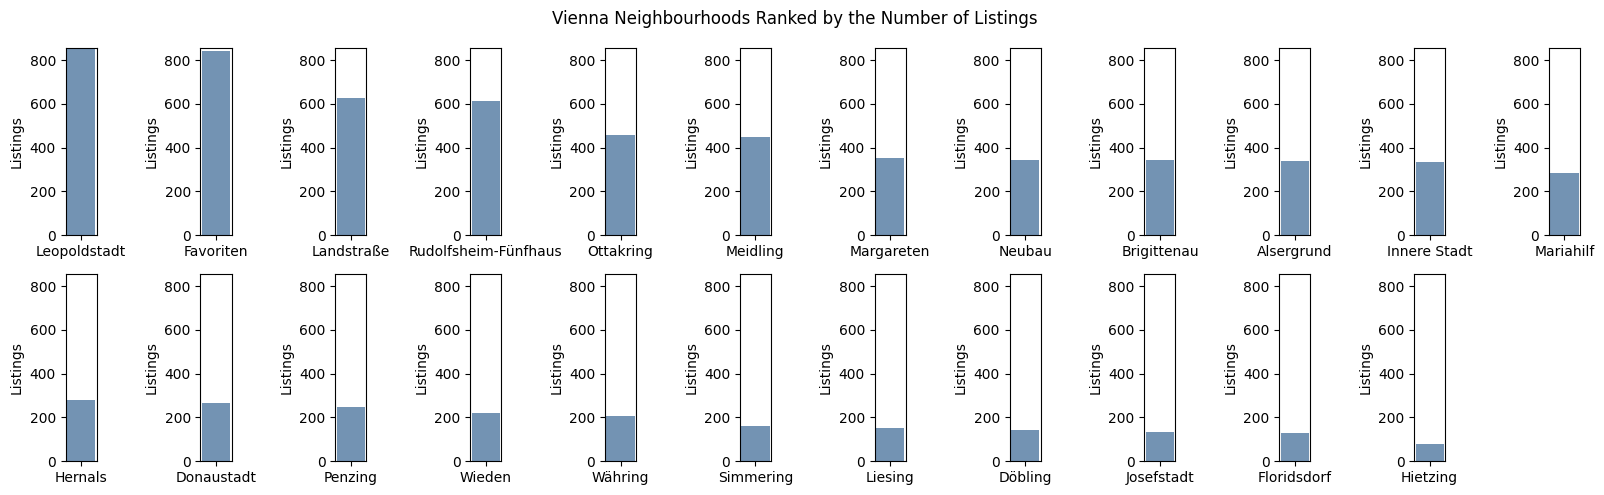

In [15]:
# No. of listings per neighbourhood
neighbourhood_count = airbnb['neighbourhoods'].value_counts().sort_values(ascending= False)

fig, axes = plt.subplots(2, 12, figsize=(16, 5))
axes = axes.flatten()

max_count = neighbourhood_count.max()

for ax, (neigh, count) in zip(axes, neighbourhood_count.items()):
    ax.bar(neigh, count, color='#7393B3')
    ax.set_ylim(0, max_count)
    ax.set_ylabel('Listings')

# Hide unused subplots
for ax in axes[len(neighbourhood_count):]:
    ax.set_visible(False)


fig.suptitle('Vienna Neighbourhoods Ranked by the Number of Listings')
plt.tight_layout()

plt.savefig(path + '/../Graphs/Distribution_Neighbourhoods.png')
plt.show()

This graph is a pure listing-count ranking, not a price ranking, so a neighbourhood being high here doesn't tell us anything about how expensive it is. <br>
Thus, the following section is dedicated to showing the neighbourhood-price relationship.

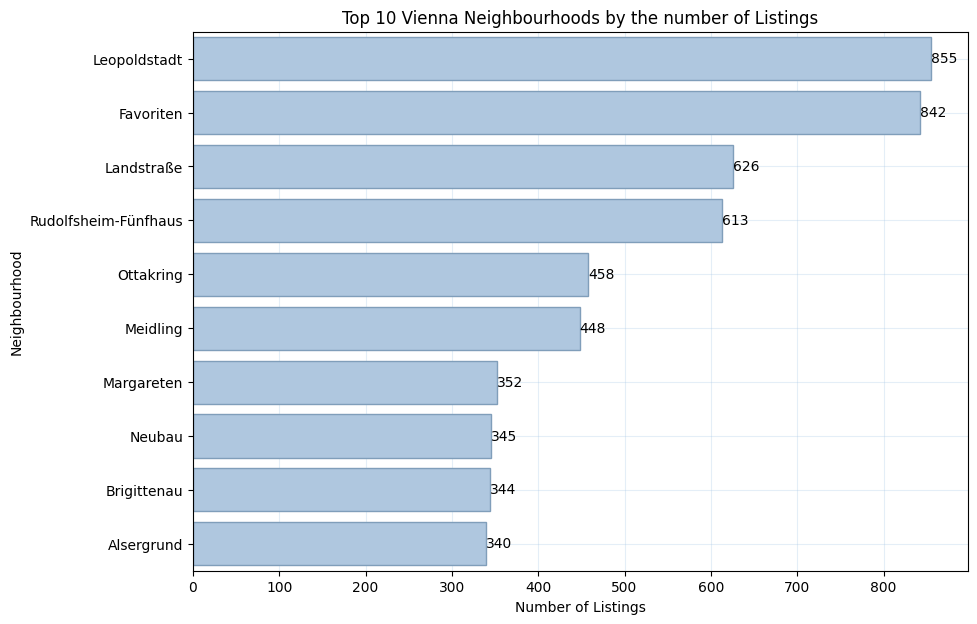

In [16]:
top_10 = airbnb['neighbourhoods'].value_counts().head(10).sort_values(ascending= False)
# As it's a categorical value, to plot only the Top10 -> convert to string just for this
top_10.index = top_10.index.astype(str)

plt.figure(figsize=(10,7))

ax = sns.barplot(
    x= top_10.values, 
    y= top_10.index,
    color='#A7C7E7',
    edgecolor= '#809EBA'
)
# Grid behind bars
plt.gca().set_axisbelow(True) 
plt.grid(axis='both', alpha=0.3, color='#A7C7E7')

ax.bar_label(ax.containers[0], fontsize=10);

plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood')

plt.title('Top 10 Vienna Neighbourhoods by the number of Listings')

plt.savefig(path + '/../Graphs/Neighbourhoods_Top10.png')
plt.show()

In [17]:
top2 = airbnb['neighbourhoods'].value_counts().head(2).sort_values(ascending= False)
percent = top2.sum()/airbnb.shape[0] * 100
print(f"Top 2: {percent:.2f} % ")

top10 = airbnb['neighbourhoods'].value_counts().head(10).sort_values(ascending= False)
perc = top10.sum()/airbnb.shape[0] * 100
print(f"Top 10: {perc:.2f} % ")

Top 2: 21.58 % 
Top 10: 66.43 % 


`Leopoldstadt and Favoriten` lead by a wide margin, together accounting for ~*21.58 %* of the total 7,863 listings. <br>
The top ten neighbourhoods together account for ~*66.43 %* of the total 7,863 (with Vienna having a total of 23 neighbourhoods).

### 3.4  # to be edited

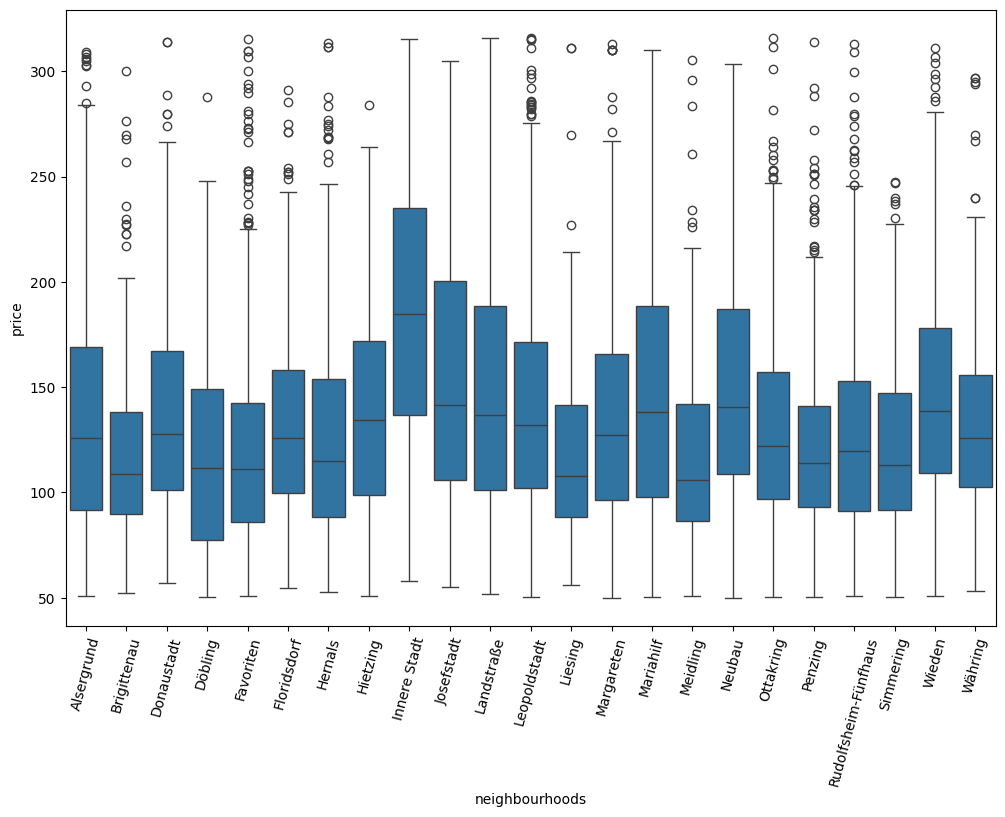

In [18]:
price_lim = airbnb['price'].quantile(0.95)
price_min = airbnb['price'].quantile(0.05)
airbnb_filtered = airbnb[(airbnb['price'] < price_lim) & (airbnb['price'] > price_min)]

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=airbnb_filtered,
    x='neighbourhoods',
    y='price'
)

plt.xticks(rotation=75)
plt.show()

### 3.5 Distribution of Room Type

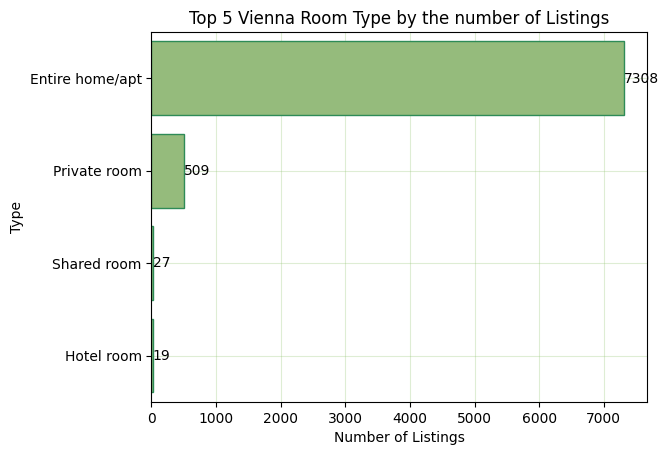

In [19]:
room = airbnb['room_type'].value_counts().sort_values(ascending= False)

ax = sns.barplot(
    x= room.values, 
    y= room.index,
    order= room.index,
    color='#93C572',
    edgecolor = '#2E8B57'
)
# Grid behind bars
plt.gca().set_axisbelow(True) 
ax.bar_label(ax.containers[0], fontsize=10);

plt.xlabel('Number of Listings')
plt.ylabel('Type')

plt.grid(axis='both', alpha=0.3, color='#93C572')
plt.title('Top 5 Vienna Room Type by the number of Listings')

plt.savefig(path + '/../Graphs/Distribution_Room_Type.png')
plt.show()

### 3.6 Geographical Distribution of Listings

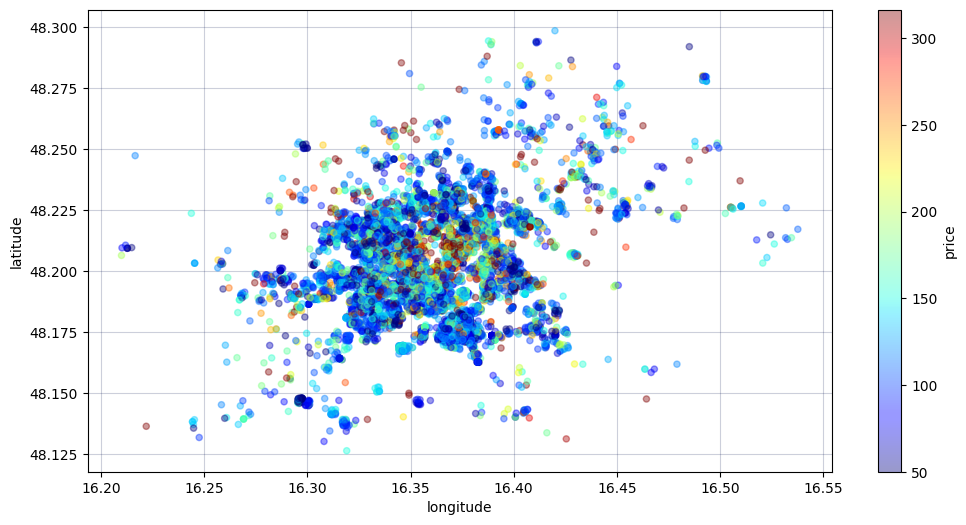

In [20]:
geo = airbnb.plot(
    kind='scatter',
    x='longitude',
    y='latitude',
    c='price',

    vmin=airbnb['price'].quantile(0.05),
    vmax=airbnb['price'].quantile(0.95),
    
    cmap=plt.get_cmap('jet'),
    colorbar=True,
    alpha=0.4,
    figsize=(12,6)
)

# Grid behind bars
plt.gca().set_axisbelow(True) 
plt.grid(axis='both', alpha=0.2, color="#000F4D")

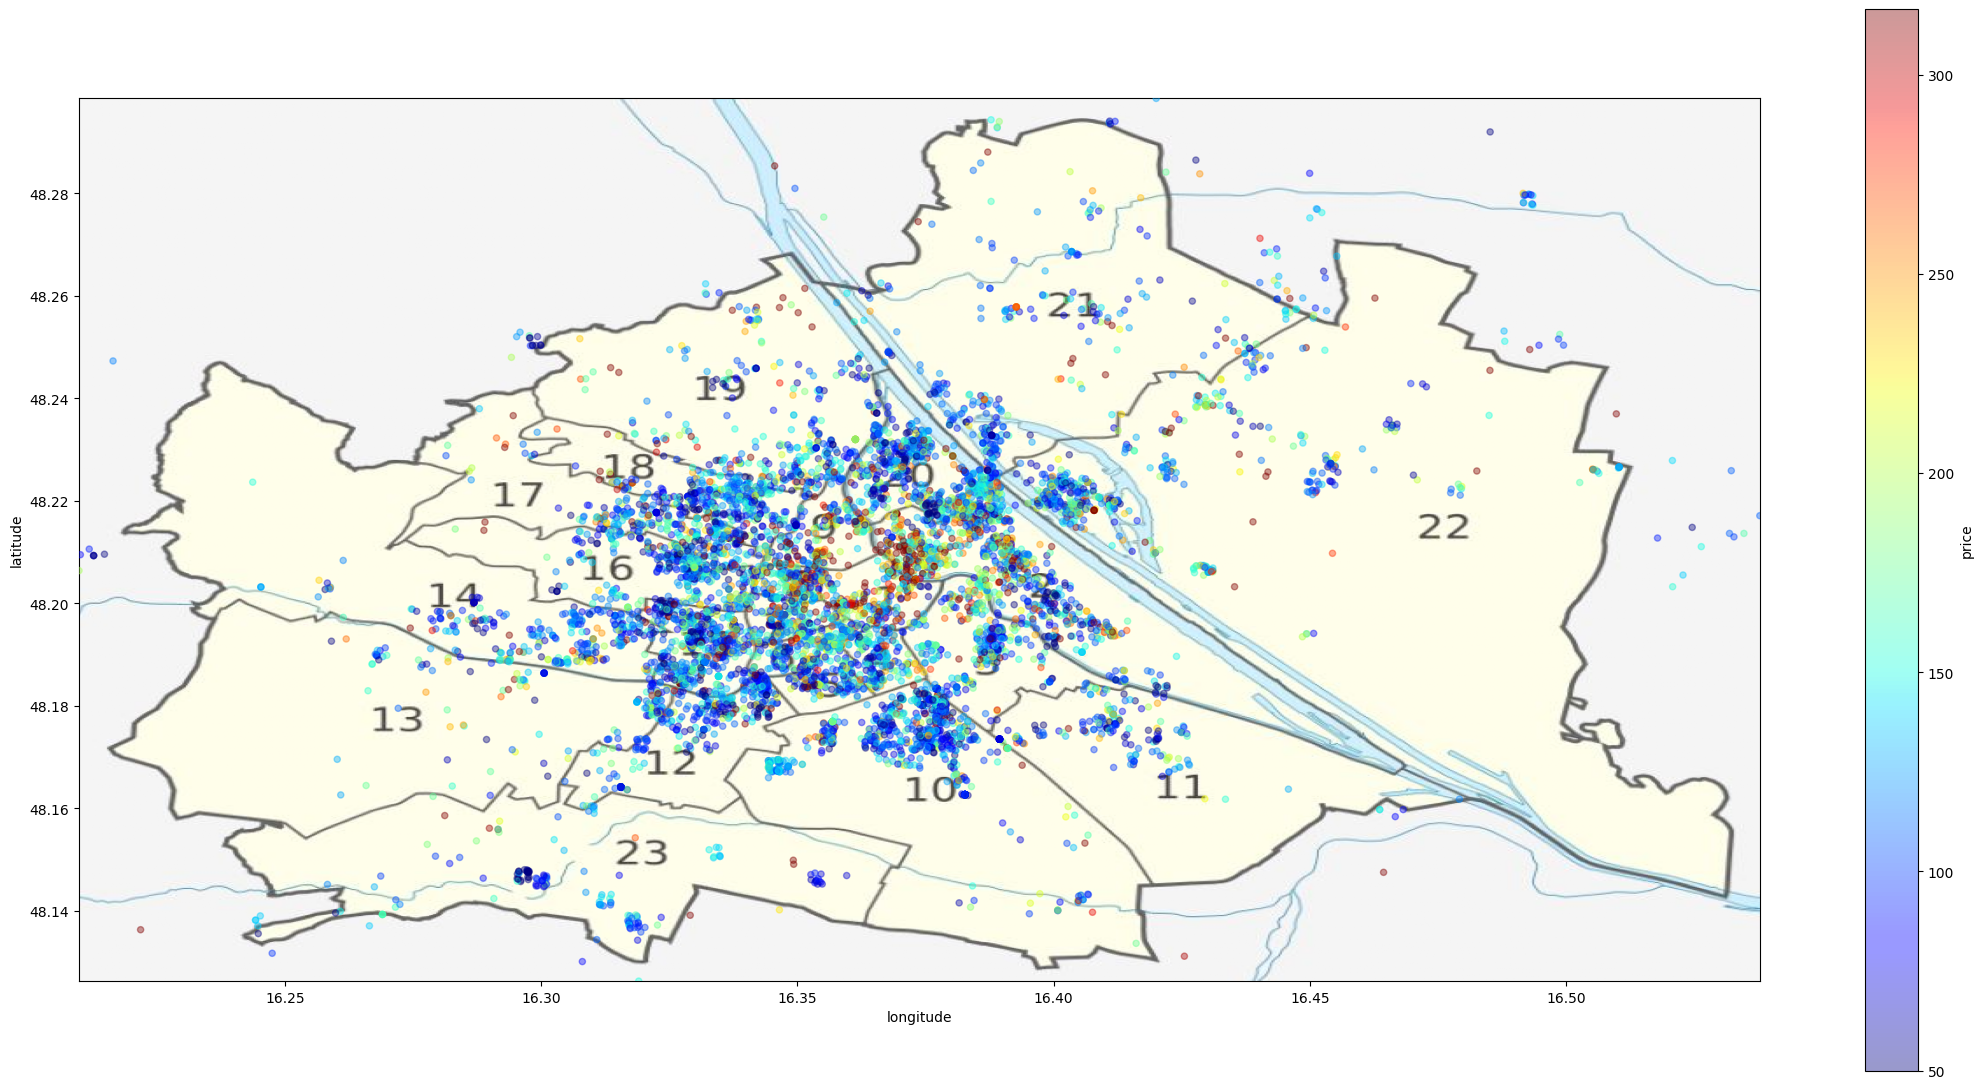

In [21]:
plt.figure(figsize=(22,11))

city_map = path + '/../data/city_map.png'
img = mpimg.imread(city_map)

plt.imshow(
    img,
    zorder= 0,
    extent= [16.209820,16.537774,  48.126310,48.298535]
)

ax= plt.gca()

airbnb.plot(
    kind='scatter',
    x='longitude', 
    y='latitude',
    c='price',
    ax=ax,

    # Exlc. extreme values
    vmin = airbnb['price'].quantile(0.05),
    vmax = airbnb['price'].quantile(0.95),

    cmap=plt.get_cmap('jet'), 
    colorbar=True, 
    alpha=0.4, 
    zorder= 5
)

plt.tight_layout()

plt.savefig(path + '/../Graphs/Geo_dist_listings.png')
plt.show()

The map above provides a nice simple visualisation tool (although the border is not entirely correct), if the user wants to interact with the map and be shown a way more accurate map, such a version is coded in the interactable map file, but it is not necesary, as some patterns in the map can already be noticed from this simpler version. 



## 4 Training the models

### Train & Test Datasplit

In [22]:
np.random.seed(21)